# Shear response to parameter

Use the emulator to see how shear signal from ridges change with parameters. We can't study this directly from the original simulations as all paramters vary at the same time in CosmoGRID.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

import json

# %ls
%cd ../

import predict
import load_data

%cd ../

/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu


I0000 00:00:1788535026.784048 1040811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788535026.784478 1040811 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788535026.828118 1040811 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788535028.009146 1040811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

/home/s2561233/Documents/lss/ridges/ridges_toolkit


In [2]:
N = 6

my_blues = LinearSegmentedColormap.from_list("", ["#18698F","#7AC011"])
norm = Normalize(vmin=0, vmax=N-1)
sm = ScalarMappable(cmap=my_blues, norm=norm)
sm.set_array([])

from matplotlib import rc
rc('text', usetex=False)
# rc('font',**{'family':'serif','serif':['Times']})

In [3]:
%cd /home/s2561233/Documents/lss/ridges/ridges_toolkit

# get radial bins, mean and stdev from metadata
with open('emu/data/metadata.json', 'r') as f:
    metadata = json.load(f)

sep_bin_center = metadata['sep_bin_center']

# choose two simulations indices to plot against prediction
idx1 = 0
idx2 = 50

all_pairs = metadata["bin_pairs"]

/home/s2561233/Documents/lss/ridges/ridges_toolkit


In [4]:
ranges = {
    'Omega_m': {'low': 0.15,  'upp': 0.45},
    'sigma8':  {'low': 0.5,   'upp': 1.3},
    'w0':      {'low': -1.25, 'upp': -0.75},
    'n_s':     {'low': 0.93,  'upp': 1.},
    'Omega_b': {'low': 0.04,  'upp': 0.05},
    'H0':      {'low': 65.,   'upp': 75.},
    'bary_Mc': {'low': 1e12,  'upp': 1e15},
    'bary_nu': {'low': -2.,    'upp': 2.}
}

fiducials = {
    'Omega_m': 0.31,
    'bary_Mc': 13.82,
    'bary_nu': 0.,
    'sigma8': 0.83,
    'w0': -1.,
    'n_s': 0.97,
    'Omega_b': 0.05,
    'H0': 68.0,
}

param_labels = {
    'Omega_m': r'$\Omega_{\rm m}$',
    'sigma8': r'$\sigma_8$',
    'w0': r'$w_0$',
    'n_s': r'$n_{\rm s}$',
    'Omega_b': r'$\Omega_{\rm b}$',
    'H0': r'$H_0$',
    'bary_Mc': r'M$_{\rm C}$',
    'bary_nu': r'$\eta$'
}

bin_l = 0
bin_s = 3

E0000 00:00:1788535028.856086 1040811 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


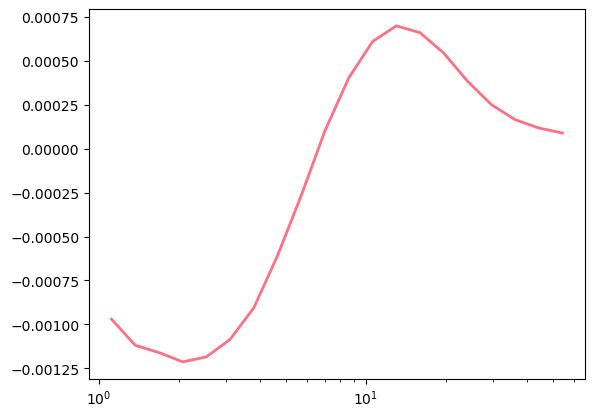

In [5]:
fiducials = {
    'Omega_m': 0.31,
    'bary_Mc': 13.82,
    'bary_nu': 0.,
    'sigma8': 0.83,
    'w0': -1.,
    'n_s': 0.97,
    'Omega_b': 0.05,
    'H0': 68.0,
}

prediction = predict.make_prediction(fiducials, bin_l, bin_s)
plt.plot(sep_bin_center, prediction[0], color='#FF7083', label='Prediction', linewidth=2)
plt.xscale('log')

In [11]:
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

param_dict = fiducials.copy()

nparams = len(fiducials)
fig, axes = plt.subplots(2, 4, figsize=(18, 6), sharex=True)#, sharey=True)
axes = axes.ravel()

for ax, par in zip(axes, fiducials.keys()):
    par_arr = np.linspace(ranges[par]['low'], ranges[par]['upp'], N)

    for i, value in enumerate(par_arr):
        param_dict[par] = value

        model_path = f'emu/models/lens{bin_l}_source{bin_s}.keras'
        prediction = predict.make_prediction(param_dict, bin_l, bin_s, model_path)

        if par == 'bary_Mc':
            label = f'{value:.0e}'
        elif par == 'Omega_m' or par == 'sigma8' or par == 'w0':
            label = f'{value:.2f}'
        elif par == 'H0':
            label = f'{value:.0f}'
        else:
            label = f'{value:.3f}'
        ax.plot(
            sep_bin_center,
            prediction[0]*1e3,
            color=sm.to_rgba(i),
            label=label
            )

    param_dict[par] = fiducials[par]
    ax.legend(title=param_labels[par], fontsize=10, title_fontsize=12, loc='lower right')
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='major', labelsize=12)

axes[0].set_ylabel(r'$\gamma_{\rm t}\times 10^{-3}$', fontsize=12)
axes[4].set_ylabel(r'$\gamma_{\rm t}\times 10^{-3}$', fontsize=12)

for ax in axes[-4:]:
    ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=12)


fig.tight_layout()
fig.savefig('emu/figs/thesis/response_to_parameters.pdf', bbox_inches='tight')

Error in callback <function _draw_all_if_interactive at 0x7428c39f7d80> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because dvipng could not be found

RuntimeError: Failed to process string with tex because dvipng could not be found

<Figure size 1800x600 with 8 Axes>

- $M_C$ --> lower shear signal at higher values of Mc as more feedback redistributes more DM (i.e. less powerful lens effect)? Signal changes more at small scales, as expected.

- $\eta$ --> ??

- $\Omega_m$ and $\sigma_8$ --> higher value means more lensing, i.e. more signal
